# Conformal Good-Turing Classification (CGTC) - Quick Start Demo

This notebook demonstrates how to use **Conformal Good-Turing Classification (CGTC)** for open-set and imbalanced classification tasks.

## What is CGTC?

CGTC is a conformal prediction framework that:
1. **Handles open-set scenarios** - Can encounter previously unseen classes at test time via a "joker" option
2. **Works with extreme class imbalance** - Uses selective sample splitting with proper re-weighting
3. **Provides valid coverage guarantees** - Even with infinite possible labels

## Key Components

- **Standard Split Conformal**: Baseline method that splits data randomly
- **Bernoulli Splitting**: Selective splitting based on label frequency for efficiency under imbalance
- **Good-Turing p-values**: Novel p-values for testing if a point belongs to an unseen class
- **Alpha allocation**: Distributing error budget across seen labels, unseen labels, and individual classes

We will provide a quick demon using the synthetic data generated from a Dirichlet Process (DP) Model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from sklearn.neighbors import LocalOutlierFactor
import sys
import os

# Add paths to custom modules
sys.path.insert(0, os.path.abspath('../third_party'))
sys.path.insert(0, '../cgtc/')

# Import ARC utilities
from arc import black_boxes, classification
from alpha_tune_function import tune_alpha_allocation_loss_all_optimized

# Import CGTC methods
from conformal_methods import (
    evaluate_prediction_sets,
    finalize_prediction_sets,
    get_preliminary_sets_naive,
    get_preliminary_sets_benchmark,
    get_preliminary_sets_Bernoulli
)
from distributions_x import ShiftedNormal
from distributions_y import DirichletProcess

# Set random seed for reproducibility
np.random.seed(42)

# Plotting configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:

def calculate_freq_one_proportion(Y_ref):
    """
    Calculate the proportion of data points that have frequency-1 labels.
    """
    unique_labels, counts = np.unique(Y_ref, return_counts=True)
    freq_one_labels = unique_labels[counts == 1]
    freq_one_mask = np.isin(Y_ref, freq_one_labels)
    freq_one_prop = np.mean(freq_one_mask)
    return freq_one_prop


def calib_prob_real(frequency, exp_prop=0.1, freq_one_prop=None):
    """
    Given a positive integer 'frequency' representing the frequency count of a label,
    returns the probability of that label being selected into the calibration set.

    Args:
        frequency: Frequency count of the label
        exp_prop: Base expected proportion (calib_size)
        freq_one_prop: Proportion of data points with frequency-1 labels
    """
    if frequency == 0:
        return 0.0
    elif frequency == 1:
        return 0.0
    else:
        # If freq_one_prop is provided, adjust the probability to maintain expected calibration size
        if freq_one_prop is not None and freq_one_prop < 1.0:
            # Adjusted probability to compensate for excluded frequency-1 labels
            # We need: adjusted_prob * (1 - freq_one_prop) = exp_prop
            adjusted_prob = exp_prop / (1 - freq_one_prop)
            # Cap at 1.0 to ensure it's a valid probability
            prob_calib = min(adjusted_prob, 1.0)
        else:
            # Fallback to base proportion if no adjustment needed
            prob_calib = exp_prop
        return prob_calib


## Data generation

In [6]:
# Data generation parameters
theta = 1000  # DP concentration parameter (controls label diversity)
num_features = 3  # Feature dimensionality
sigma = 0.000005  # Variance of feature distribution around labels

# Sample sizes
n_ref = 2000  # Reference data (training + calibration)
n_test = 1000  # Test data

# Create data distribution
label_dist = DirichletProcess(theta=theta)
feature_dist = ShiftedNormal(num_features, sigma)

class DataDistribution:
    def __init__(self, label_dist, feature_dist):
        self.label_dist = label_dist
        self.feature_dist = feature_dist

    def sample(self, n, random_state=None):
        Y = self.label_dist.sample(n, random_state=random_state)
        X = self.feature_dist.sample(Y, random_state=random_state)
        return X, Y

data_dist = DataDistribution(label_dist, feature_dist)

# Generate data
X_all, Y_all = data_dist.sample(n_ref + n_test, random_state=42)

# Split into reference and test
X_ref, Y_ref = X_all[:n_ref], Y_all[:n_ref]
X_test, Y_test = X_all[n_ref:], Y_all[n_ref:]

print(f"Reference data: {len(Y_ref)} samples")
print(f"Test data: {len(Y_test)} samples")
print(f"\nUnique labels in reference: {len(np.unique(Y_ref))}")
print(f"Unique labels in test: {len(np.unique(Y_test))}")

# Check for unseen labels
seen_labels = set(Y_ref)
unseen_mask = ~np.isin(Y_test, list(seen_labels))
print(f"\nProportion of test points with unseen labels: {unseen_mask.mean():.2%}")

Reference data: 2000 samples
Test data: 1000 samples

Unique labels in reference: 1105
Unique labels in test: 692

Proportion of test points with unseen labels: 32.90%


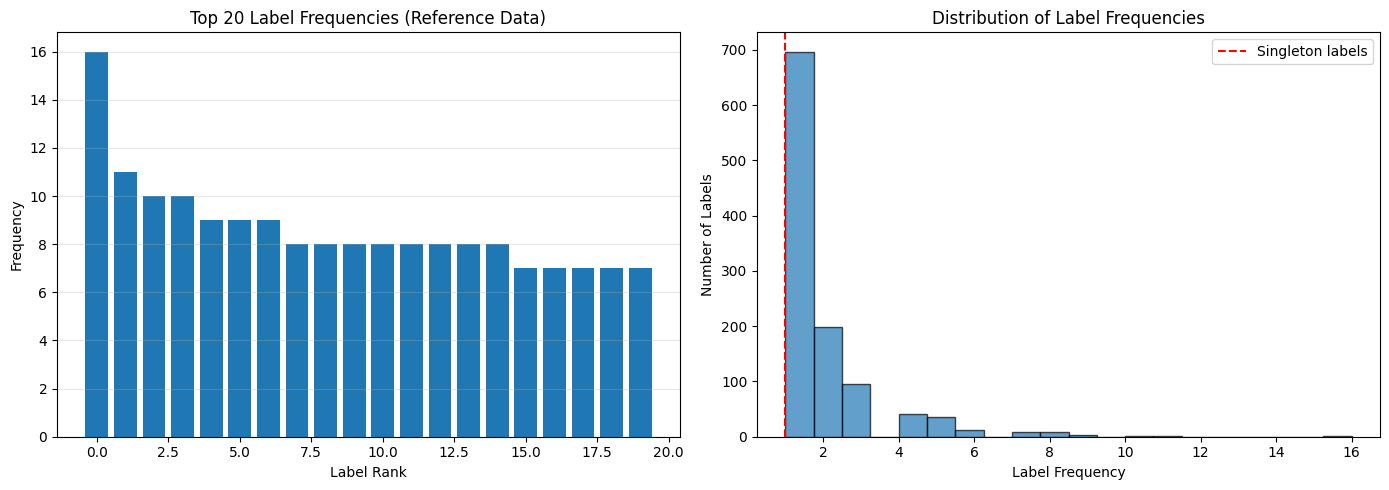

Labels appearing only once: 697 (63.1%)
Labels appearing ≤5 times: 1069 (96.7%)
Most common label frequency: 16
Median label frequency: 1.0


In [7]:
# Count label frequencies
unique_labels, counts = np.unique(Y_ref, return_counts=True)
sorted_idx = np.argsort(counts)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of label frequencies (top 20)
top_n = min(20, len(unique_labels))
axes[0].bar(range(top_n), counts[sorted_idx[:top_n]])
axes[0].set_xlabel('Label Rank')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Top {top_n} Label Frequencies (Reference Data)')
axes[0].grid(axis='y', alpha=0.3)

# Distribution of frequencies
axes[1].hist(counts, bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Label Frequency')
axes[1].set_ylabel('Number of Labels')
axes[1].set_title('Distribution of Label Frequencies')
axes[1].axvline(x=1, color='red', linestyle='--', label='Singleton labels')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"Labels appearing only once: {np.sum(counts == 1)} ({np.mean(counts == 1):.1%})")
print(f"Labels appearing ≤5 times: {np.sum(counts <= 5)} ({np.mean(counts <= 5):.1%})")
print(f"Most common label frequency: {counts.max()}")
print(f"Median label frequency: {np.median(counts):.1f}")

## Alpha-allocation

In [17]:
# Initialize classifier (k-NN for open-set)
n_neighbors = 5
classifier = black_boxes.OpenSetKNN(
    calibrate=False,
    n_neighbors=n_neighbors,
    weights='distance',
    algorithm='auto',
    n_jobs=-1
)

# One-class classifier for novelty detection
occ = LocalOutlierFactor(n_neighbors=1, novelty=True)

print(f"\nClassifier: k-NN (k={n_neighbors})")
print(f"OCC: Local Outlier Factor")

# Conformal prediction parameters
alpha_total = 0.1  # Total error budget (10%)
calib_size = 0.5  # Proportion of reference data for calibration
alpha_allocation_method = "adaptive"
seed = 123

# Allocate alpha budget across three types of errors:
# 1. alpha_class: misclassifying among seen classes
# 2. alpha_unseen: missing an unseen class (false negative for joker)
# 3. alpha_seen: including joker when label is actually seen (false positive for joker)

if alpha_allocation_method == "fixed":
    # using a fixed budget
    alpha_class = alpha_total / 3
    alpha_unseen = alpha_total / 3
    alpha_seen = alpha_total / 3
elif alpha_allocation_method == "adaptive":
    lambda_weight = 0.5 # regularization parameter when using the adaptive alpha allocation
    # Calculate proportion of frequency-1 labels
    freq_one_prop = calculate_freq_one_proportion(Y_ref)

    # Create adjusted calibration probability function
    calib_prob_adjusted = partial(calib_prob_real,
                                  exp_prop=calib_size,
                                  freq_one_prop=freq_one_prop)

    alpha_class, alpha_unseen, alpha_seen, tuning_results = tune_alpha_allocation_loss_all_optimized(
                X_ref, Y_ref,
                alpha_total=alpha_total,
                lambda_weight=lambda_weight,
                n_splits=2, # 10,
                alpha_step=0.005,
                classifier=classifier,
                occ=occ,
                calibration_probability=calib_prob_adjusted,  # Use adjusted function
                calib_size=calib_size,
                pvalue_method='XGT',
                random_state=seed,
                beta=None,
                splitting_method='random'  # Uses the converted string value
            )


print(f"Total error budget: {alpha_total}")
print(f"  Alpha (class): {alpha_class:.3f}")
print(f"  Alpha (unseen): {alpha_unseen:.3f}")
print(f"  Alpha (seen): {alpha_seen:.3f}")


Classifier: k-NN (k=5)
OCC: Local Outlier Factor
Proportion of frequency-1 labels in reference data: 0.348

Optimized tuning with loss function (λ=0.5)
Testing 4 alpha_old values: [0, 0.01, 0.02, 0.05]
For each alpha_old, α_class grid = {0.01, 0.015, 0.020, ...} with fixed step 0.005 up to α_total - α_old.
Precomputing baseline sets for each fold...
Random split: Size of all data: 1000. Size of calibration set: 500. 
Random split: Size of all data: 1000. Size of calibration set: 500. 
Precomputing preliminary sets for 19 unique α_class values...


Caching preliminary sets:   0%|          | 0/19 [00:00<?, ?it/s]

Random split: Size of all data: 1000. Size of calibration set: 500. 


Caching preliminary sets:   0%|          | 0/19 [00:04<?, ?it/s]

Random split: Size of all data: 1000. Size of calibration set: 500. 


...

Random split: Size of all data: 1000. Size of calibration set: 500. 


Caching preliminary sets: 100%|██████████| 19/19 [02:56<00:00,  9.31s/it]



Evaluating 60 alpha combinations using cached data...


α_class (α_old=0.05): 100%|██████████| 9/9 [01:10<00:00,  7.84s/it]



Best allocation found (minimum loss):
  α_class = 0.090
  α_new = 0.010
  α_old = 0.000
  Sum = 0.100 (should equal 0.100)
  Average loss = 0.609
  Components: NormSize=0.959, JokerWaste=0.260
  Average coverage = 0.958
Total error budget: 0.1
  Alpha (class): 0.090
  Alpha (unseen): 0.010
  Alpha (seen): 0.000


In [19]:
# List of all unique labels seen in the training set
seen_labels = np.unique(Y_ref)
num_unique_labels = len(seen_labels)

# Calculate proportion of new/unseen test labels
unseen_mask = ~np.isin(Y_test, seen_labels)
prop_unseen = np.mean(unseen_mask)
num_unseen = np.sum(unseen_mask)

# Also calculate number of unique unseen labels if you're interested
unique_unseen_labels = np.unique(Y_test[unseen_mask])
num_unique_unseen = len(unique_unseen_labels)

Proportion of unseen test labels: 0.329 (329/1000 points)
Number of unique unseen labels in test: 289


## Build CGTC prediction sets

In [22]:
# Using power weights to combine the p-values for testing individual hypothesis for seen hypothesis
# Using a constant default beta
best_beta = 1.6

methods_list = {
    'Method (random splitting)': get_preliminary_sets_naive, # CGTC with random splitting
    'Method (Bernoulli)': get_preliminary_sets_Bernoulli, # CGTC with Bernoulli splitting
}

# Iterate over each method and evaluate
for method_name, method_function in methods_list.items():
    print(f"Begin running {method_name}")

    if method_name == 'Method (Bernoulli)':
        decoded_prelim_sets = method_function(
            X_ref, Y_ref, X_test,
            alpha_prime=alpha_class,
            black_box=classifier,
            calibration_probability=calib_prob_adjusted,  # Use adjusted function
            random_state=seed
        )
    elif method_name == 'Method (random splitting)':
        decoded_prelim_sets = method_function(
                X_ref, Y_ref, X_test,
                alpha_prime=alpha_class,
                black_box=classifier,
                calib_size=calib_size,
                random_state=seed
            )


Begin running Method (random splitting)
Random split: Size of all data: 2000. Size of calibration set: 1000. 
Begin running Method (Bernoulli)
Bernoulli: Size of all data: 2000. Size of calibration set: 1001. 
  Alpha: 0.0900
  Calibration scores range: [-0.9094, 0.0438]
  Calibration scores mean: -0.4533, std: 0.2760
  Alpha_max range: [0.0462, 0.9994]
  Alpha_max mean: 0.5433, std: 0.2760
  Number of unique labels: 1105
  Number of calibration points: 1001

  Permuted probability statistics (first 5 candidates):
    Candidate 0: sum=1018.5248, mean=1.0175, std=1.0225, range=[0.0000, 4.3003], alpha_calib=0.2378
    Candidate 1: sum=236.8480, mean=0.2366, std=0.2378, range=[0.0000, 1.0000], alpha_calib=0.2309
    Candidate 2: sum=236.8480, mean=0.2366, std=0.2378, range=[0.0000, 1.0000], alpha_calib=0.2309
    Candidate 3: sum=1015.2244, mean=1.0142, std=1.0172, range=[0.0000, 4.3003], alpha_calib=0.2371
    Candidate 4: sum=236.8480, mean=0.2366, std=0.2378, range=[0.0000, 1.0000], al

## Applying different conformal Good-Turing p-values and evaluate prediction sets

In [23]:
# Initialize an empty data frame to store results
results_df = pd.DataFrame()

# For each p-value approach
for pvalue_method in ['GT', 'XGT', 'RGT']:
    # Skip p-value computation for the benchmark methods

    # Compute final sets with dual testing problem
    final_sets = finalize_prediction_sets(
        decoded_prelim_sets,
        X_ref, Y_ref, X_test,
        pvalue_method,
        alpha_unseen, alpha_seen,  # Pass both alpha parameters
        occ=occ,
        random_state=seed,
        beta=best_beta
    )

    # Evaluate the prediction sets
    results_df = evaluate_prediction_sets(final_sets, Y_test, Y_ref, verbose=False)

    # Add the method name to the results
    results_df['method'] = method_name
    results_df['pvalue_method'] = pvalue_method
    results_df['num_unique_labels'] = num_unique_labels

    # Add proportion of unseen test labels to results
    results_df['prop_unseen_test'] = prop_unseen
    results_df['num_unseen_test'] = num_unseen

    # Add alpha values to results
    results_df['alpha_class'] = alpha_class
    results_df['alpha_unseen'] = alpha_unseen
    results_df['alpha_seen'] = alpha_seen

results_df

,Size (?),Coverage (?),Size,Coverage,Prop ?,Prop empty,Size_std,Unseen Size,Seen Size,Seen Coverage,...,Size (very_common) fixed,Count (very_common) fixed,method,pvalue_method,num_unique_labels,prop_unseen_test,num_unseen_test,alpha_class,alpha_unseen,alpha_seen
0,119.226,0.92,118.264,0.607,0.962,0.0,1.190926,118.762918,118.019374,0.90462,...,116.741176,85,Method (Bernoulli),RGT,1105,0.329,329,0.09,0.01,0.0
